Our data is in assignments\Assignment4\transformer_data.csv

It is "time","Y","Ta","S","I" 

It means 

• Yt: The transformer station temperature (◦C).

• Ta,t: The outdoor air temperature (◦C).

• Φs,t: The horizontal global solar radiation (W/m2) --> variable S in dataset

• ΦI,t: The load on the transformer station (kA). --> variable I in dataset


In this exercise, we shall develop models to predict the temperature evolution in transformer station
in a DSO (distribution system operator, distributing electricity from high-voltage grid out to the end
consumer) grid. Transformer stations are vital to the electricity transportation system, and having
the operate optimally is advantagous.
A brief introduction to a transformer station. Roughly speaking, a transformer station receives electricity at a high voltage and sends out electricity at a lower voltage. In this process, some energy is
lost in the transformer and converted into heat. DSO transformer stations typically use oil for cooling
(like water cooling, just with oil). The highest temperature inside the transformer station needs to be
below a given threshold in order to limit the speed of degradation of the transformer station and to
avoid it catching fire. In this data, a good approximation to this temperature is measured. We would
now like a model that is able to predict this temperature.


This is useful because we will be able to predict dangerous temperatures before they happen, and
because we will be able to relate the input (electricity load) to the output (temperature).

We want to relate the impact of I on Y


We have 7 days of hourly data, so 7*24 = 168 data points 

# 2.1

Load the provided dataset.

• Plot all four variables (Yt, Ta,t, Φs,t, ΦI,t) together in a single figure, using different colors
or panels.

• Use appropriate labels and time axes for clarity.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

fp = "C:\\Users\\leahi\\Documents\\DTU\\Time Series Analysis\\assignments\\Assignment4\\transformer_data.csv"
df = pd.read_csv(fp)

In [ ]:
# Use the numeric hour `time` as x-axis
x = df["time"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, df["Y"], color="tab:red", label="Y: transformer temperature")
ax.plot(x, df["Ta"], color="tab:blue", label="Ta: outdoor air temperature")
ax.plot(x, df["S"], color="tab:orange", label="S: solar radiation")
ax.plot(x, df["I"], color="tab:green", label="I: transformer load")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Value")
ax.set_title("Transformer station data over time")
ax.grid(alpha=0.3)
ax.legend(ncol=2, frameon=False)

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    ax.set_xticks(xt)
except Exception:
    pass

plt.tight_layout()
plt.show()

In [ ]:


# Use the numeric hour `time` as x-axis
x = df["time"]

# Plot in 4 stacked panels (shared x-axis)
cols = ["Y", "Ta", "S", "I"]
colors = ["tab:red", "tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 8))
for ax, col, c in zip(axes, cols, colors):
    ax.plot(x, df[col], color=c)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (hours)")
fig.suptitle("Transformer data: Y (temp), Ta (air), S (solar), I (load)", y=1.02)
plt.tight_layout()

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    axes[-1].set_xticks(xt)
except Exception:
    pass

plt.show()

# 2.2

Estimate a 1-dimensional state-space model: 
We now aim to fit a simple 1-dimensional state-space model of the form:
Xt+1 = AXt + But + Ge1,t,
Yt = CXt + e2,t,
where ut = [Ta,t,Φs,t,ΦI,t]T is the input vector. (Note: Here we use G to scale the system noise.)
You will use the provided R functions in functions exercise2.R, but you must fill in missing
parts.


Implement:
•Complete the functions kf logLik dt and estimate dt.
•Map the parameter vector to the appropriate matrices A, B, G, C, Σx, Σy.
•Estimate the model parameters by maximizing the likelihood (use optim).
•Adjust the initial guesses and parameter bounds if necessary to achieve a good fit

## 2.2 — Physical 1-D resistor–capacitor (RC) state-space model

Instead of an abstract 1-D model where `A`, `B` are free numbers, we use a **lumped RC thermal model** whose parameters have physical meaning. The transformer station is treated as a single thermal mass with heat capacity $C_x$ that exchanges heat with the ambient air through a thermal resistance $R_{xa}$, and is heated by solar radiation $\Phi_{s,t}$ and electrical load $\Phi_{I,t}$:

$$
C_x\,\dot X(t)=\frac{1}{R_{xa}}\bigl(T_a(t)-X(t)\bigr)+a\,\Phi_s(t)+b\,\Phi_I(t)
$$

Dividing by $C_x$:

$$
\dot X(t)=-\frac{1}{\tau}\,X(t)+\frac{1}{\tau}\,T_a(t)+A_s\,\Phi_s(t)+A_I\,\Phi_I(t)
$$

with the **identifiable** physical parameters

$$
\tau = C_x R_{xa}\ [\text{h}],\quad
A_s = \tfrac{a}{C_x}\ [\text{°C}\cdot\text{m}^2/\text{W}\cdot\text{h}],\quad
A_I = \tfrac{b}{C_x}\ [\text{°C}/\text{kA}\cdot\text{h}].
$$

(Note: from observations of $Y$ alone, $C_x$ and $R_{xa}$ can only be identified through their product $\tau$ — and $a,b$ only through $A_s = a/C_x$, $A_I = b/C_x$ — so we estimate $\tau, A_s, A_I$ directly.)

Continuous-time state-space form with $u=[T_a,\Phi_s,\Phi_I]^T$:

$$
A_c=-\tfrac{1}{\tau},\qquad B_c=\bigl[\tfrac{1}{\tau},\ A_s,\ A_I\bigr]
$$

We discretize with sampling step $\Delta t = 1$ hour using the block matrix exponential (§32–33 of the notes):

$$
\exp\!\left(\begin{bmatrix}A_c & B_c\\ 0 & 0\end{bmatrix}\Delta t\right)
=\begin{bmatrix}A_d & B_d\\ 0 & I\end{bmatrix}
$$

giving the discrete-time model
$$
X_{t+1}=A_d X_t + B_d u_t + G\,e_{1,t},\qquad Y_t = X_t + e_{2,t},
$$
with $G=1$, $e_{1,t}\sim\mathcal N(0,\sigma_1^2)$, $e_{2,t}\sim\mathcal N(0,\sigma_2^2)$.

**Estimated parameters** (positive — optimized in log-space): $\tau,\,A_s,\,A_I,\,\sigma_1,\,\sigma_2$.
The log-likelihood is built from the Kalman one-step innovations (§13, §20 of the notes).


In [6]:
import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize

# ---- Data: state-space ingredients ---------------------------------------
# Inputs u_t = [Ta, S, I]^T  (rows = time)
U = df[["Ta", "S", "I"]].to_numpy()
Y = df["Y"].to_numpy()
N = len(Y)
dt = 1.0  # sampling interval = 1 hour

# ---- Build discrete-time RC matrices from identifiable physical params ---
def build_discrete(tau, As, AI, dt=1.0):
    """Discretize the continuous-time 1-state RC model with the block matrix
    exponential.  Parameters:
        tau : thermal time constant (h),  Ac = -1/tau
        As  : solar gain  (Bc coeff. on S)
        AI  : load  gain  (Bc coeff. on I)
    Returns scalar A_d and 1x3 row B_d."""
    Ac = np.array([[-1.0 / tau]])
    Bc = np.array([[1.0 / tau, As, AI]])
    # Block matrix for exact joint discretization of A and B
    M = np.zeros((4, 4))
    M[0:1, 0:1] = Ac
    M[0:1, 1:4] = Bc
    Md = expm(M * dt)
    Ad = Md[0:1, 0:1]
    Bd = Md[0:1, 1:4]
    return Ad, Bd

# ---- Kalman filter + log-likelihood for the RC model ---------------------
def kf_logLik_rc(par, Y, U, dt=1.0, X0=None, P0=1e2, return_filter=False):
    """par = [log tau, log As, log AI, log sigma1, log sigma2].
    Physical parameters are forced positive via the log-parameterization."""
    tau, As, AI, sigma1, sigma2 = np.exp(par)

    Ad, Bd = build_discrete(tau, As, AI, dt)
    C = np.array([[1.0]])
    Q = np.array([[sigma1 ** 2]])      # G * sigma1^2 * G^T, with G = 1
    R = np.array([[sigma2 ** 2]])

    n = 1
    # Initialization: use first observation as a reasonable guess (§4, case 3)
    x_est = np.array([[Y[0] if X0 is None else X0]])
    P_est = np.array([[P0]])

    Tn = len(Y)
    logLik = 0.0

    if return_filter:
        x_pred_hist = np.zeros(Tn)
        x_filt_hist = np.zeros(Tn)
        P_pred_hist = np.zeros(Tn)
        P_filt_hist = np.zeros(Tn)
        innov_hist  = np.zeros(Tn)
        S_hist      = np.zeros(Tn)

    for t in range(Tn):
        # --- Prediction step (using input at time t-1 for X_t; at t=0 we
        #     use the prior directly) ----------------------------------------
        if t == 0:
            x_pred = x_est
            P_pred = P_est
        else:
            u_prev = U[t - 1].reshape(3, 1)
            x_pred = Ad @ x_est + Bd @ u_prev
            P_pred = Ad @ P_est @ Ad.T + Q

        # --- Innovation step ----------------------------------------------
        y_pred = C @ x_pred
        S_t    = C @ P_pred @ C.T + R
        innov  = Y[t] - y_pred[0, 0]

        # --- Log-likelihood contribution (Gaussian) -----------------------
        logLik += -0.5 * (np.log(2 * np.pi * S_t[0, 0]) + innov ** 2 / S_t[0, 0])

        # --- Update step --------------------------------------------------
        K_t   = P_pred @ C.T / S_t[0, 0]
        x_est = x_pred + K_t * innov
        P_est = (np.eye(n) - K_t @ C) @ P_pred

        if return_filter:
            x_pred_hist[t] = x_pred[0, 0]
            x_filt_hist[t] = x_est[0, 0]
            P_pred_hist[t] = P_pred[0, 0]
            P_filt_hist[t] = P_est[0, 0]
            innov_hist[t]  = innov
            S_hist[t]      = S_t[0, 0]

    if return_filter:
        return {
            "logLik": float(logLik),
            "x_pred": x_pred_hist, "P_pred": P_pred_hist,
            "x_filt": x_filt_hist, "P_filt": P_filt_hist,
            "innovation": innov_hist, "S": S_hist,
            "params": dict(tau=tau, As=As, AI=AI,
                           sigma1=sigma1, sigma2=sigma2),
        }
    return float(logLik)

def neg_logLik_rc(par, Y, U, dt=1.0):
    return -kf_logLik_rc(par, Y, U, dt)


In [ ]:
# ---- Estimate the RC parameters by maximum likelihood --------------------
# Physical-ish initial guesses:
#   tau      ~ a few hours  (thermal inertia of the transformer station)
#   As, AI   small positive gains
#   sigma1   process-noise std (modelling error in °C/h)
#   sigma2   measurement-noise std (sensor noise in °C, > 0.05 realistic)
start_phys = dict(tau=3.0, As=1e-3, AI=0.5, sigma1=0.5, sigma2=0.2)
par_names = ["tau", "As", "AI", "sigma1", "sigma2"]
par0 = np.log([start_phys[k] for k in par_names])

# Bounds in log-space (sigma2 floored at 0.05 °C — realistic sensor noise)
log_lb = np.log([0.1,  1e-6, 1e-4, 1e-3, 0.05])
log_ub = np.log([100., 1e1,  1e2,  10.,  10.  ])

# Try several random restarts to avoid the local-optimum trap
rng = np.random.default_rng(0)
best = None
for k in range(8):
    if k == 0:
        p_init = par0
    else:
        p_init = par0 + rng.normal(scale=1.0, size=par0.size)
        p_init = np.clip(p_init, log_lb, log_ub)
    r = minimize(
        neg_logLik_rc, p_init, args=(Y, U, dt),
        method="L-BFGS-B",
        bounds=list(zip(log_lb, log_ub)),
        options=dict(maxiter=500, ftol=1e-10, gtol=1e-8),
    )
    if (best is None) or (r.fun < best.fun):
        best = r

res = best
par_hat = res.x
phys_hat = dict(zip(par_names, np.exp(par_hat)))

print(f"Optimization success: {res.success} | neg-logLik = {res.fun:.4f}")
print("Estimated identifiable physical parameters:")
for k in par_names:
    print(f"  {k:7s} = {phys_hat[k]: .6g}")

# Show which parameters are sitting on a bound (warning signal)
at_lb = np.isclose(par_hat, log_lb, atol=1e-4)
at_ub = np.isclose(par_hat, log_ub, atol=1e-4)
if at_lb.any() or at_ub.any():
    print("\nWARNING: parameters at a bound:")
    for i, name in enumerate(par_names):
        if at_lb[i]: print(f"  {name} at LOWER bound ({np.exp(log_lb[i]):.4g})")
        if at_ub[i]: print(f"  {name} at UPPER bound ({np.exp(log_ub[i]):.4g})")

# Resulting discrete-time matrices and 1-step state-transition coefficient
Ad_hat, Bd_hat = build_discrete(phys_hat["tau"], phys_hat["As"], phys_hat["AI"], dt)
print(f"\nDiscrete-time A_d  = {Ad_hat[0,0]:.4f}   (≈ exp(-Δt/τ))")
print(f"Discrete-time B_d  = [{Bd_hat[0,0]:.4g}, {Bd_hat[0,1]:.4g}, {Bd_hat[0,2]:.4g}]"
      "   (coeffs on Ta, S, I)")


Optimization success: True | neg-logLik = 187.0635
Estimated identifiable physical parameters:
  tau     =  2.55311
  As      =  0.00198686
  AI      =  0.36037
  sigma1  =  0.727538
  sigma2  =  0.001

  sigma2 at LOWER bound (0.001)

Discrete-time A_d  = 0.6759   (≈ exp(-Δt/τ))
Discrete-time B_d  = [0.3241, 0.001644, 0.2982]   (coeffs on Ta, S, I)


In [9]:
# ---- Explicit parameter-vector -> matrices map ---------------------------
# θ = [log τ, log A_s, log A_I, log σ_1, log σ_2]   (estimated in log-space)
# maps to the discrete-time state-space matrices:
#   X_{t+1} = A X_t + B u_t + G e_{1,t},   e_{1,t} ~ N(0, Σ_x)
#   Y_t     = C X_t + e_{2,t},             e_{2,t} ~ N(0, Σ_y)

def theta_to_matrices(par, dt=1.0):
    tau, As, AI, sigma1, sigma2 = np.exp(par)
    Ad, Bd = build_discrete(tau, As, AI, dt)       # 1x1, 1x3
    A      = Ad                                     # state-transition matrix
    B      = Bd                                     # input matrix
    G      = np.array([[1.0]])                      # process-noise loading
    C      = np.array([[1.0]])                      # observation matrix
    Sigma_x = np.array([[sigma1 ** 2]])             # process-noise covariance
    Sigma_y = np.array([[sigma2 ** 2]])             # observation-noise covariance
    return A, B, G, C, Sigma_x, Sigma_y

A_hat, B_hat, G_hat, C_hat, Sx_hat, Sy_hat = theta_to_matrices(par_hat, dt)

print("State-space matrices at the MLE:")
print(f"  A  = {A_hat}")
print(f"  B  = {B_hat}        (columns: Ta, S, I)")
print(f"  G  = {G_hat}")
print(f"  C  = {C_hat}")
print(f"  Σx = {Sx_hat}        (= σ₁² = {Sx_hat[0,0]:.4g})")
print(f"  Σy = {Sy_hat}        (= σ₂² = {Sy_hat[0,0]:.4g})")


State-space matrices at the MLE:
  A  = [[0.67592132]]
  B  = [[0.32407868 0.00164394 0.29817338]]        (columns: Ta, S, I)
  G  = [[1.]]
  C  = [[1.]]
  Σx = [[0.52931173]]        (= σ₁² = 0.5293)
  Σy = [[1.e-06]]        (= σ₂² = 1e-06)


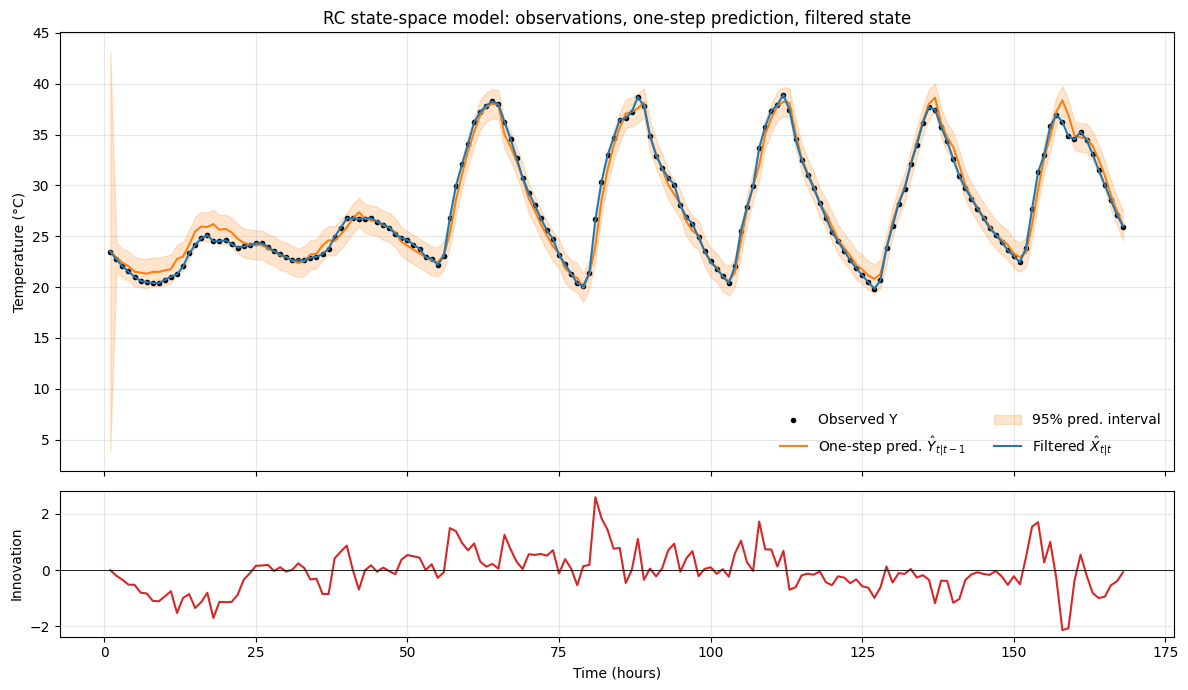

Innovation mean  = -0.0527
Innovation std   =  0.7256
RMSE one-step    =  0.7254 °C


In [10]:
# ---- Run the Kalman filter at the MLE and visualise the fit --------------
kf = kf_logLik_rc(par_hat, Y, U, dt, return_filter=True)

x_pred = kf["x_pred"]
x_filt = kf["x_filt"]
sd_pred = np.sqrt(kf["S"])  # std of one-step-ahead prediction of Y

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

ax = axes[0]
ax.plot(df["time"], Y, "k.", label="Observed Y")
ax.plot(df["time"], x_pred, color="tab:orange",
        label=r"One-step pred. $\hat Y_{t|t-1}$")
ax.fill_between(df["time"], x_pred - 1.96 * sd_pred, x_pred + 1.96 * sd_pred,
                color="tab:orange", alpha=0.2, label="95% pred. interval")
ax.plot(df["time"], x_filt, color="tab:blue",
        label=r"Filtered $\hat X_{t|t}$")
ax.set_ylabel("Temperature (°C)")
ax.set_title("RC state-space model: observations, one-step prediction, filtered state")
ax.legend(ncol=2, frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df["time"], kf["innovation"], color="tab:red")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Innovation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quick residual diagnostics
innov = kf["innovation"]
print(f"Innovation mean  = {innov.mean(): .4f}")
print(f"Innovation std   = {innov.std(ddof=1): .4f}")
print(f"RMSE one-step    = {np.sqrt((innov**2).mean()): .4f} °C")


n observations       = 168
# parameters (k)     = 5
log-likelihood       = -187.0635
AIC                  = 384.1270
BIC                  = 399.7468
Innovation mean      = -0.0527
Innovation std       =  0.7256
Std-innov mean       = -0.0724    (expect ≈ 0)
Std-innov std        =  0.9974    (expect ≈ 1)

Ljung-Box test on standardised innovations:
       lb_stat     lb_pvalue
10  215.029428  1.171980e-40
20  261.657479  5.047314e-44


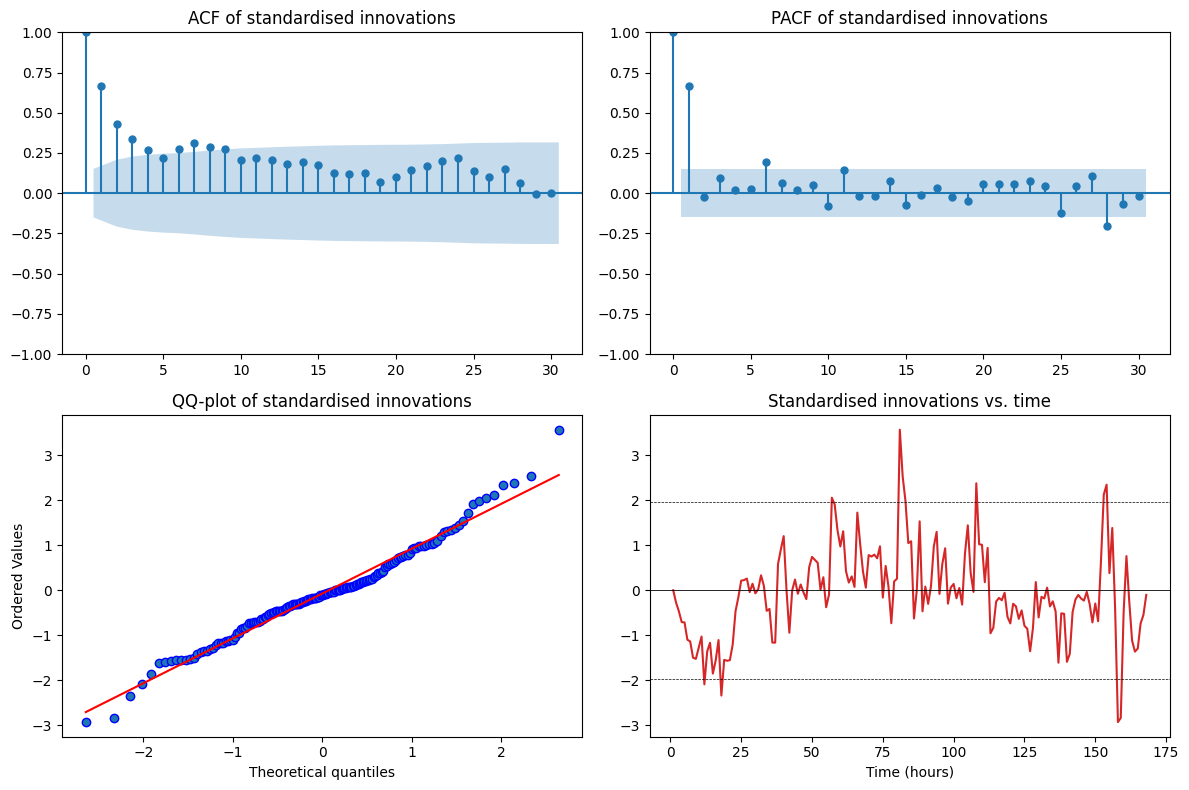

In [11]:
# ---- Residual diagnostics: ACF, PACF, QQ-plot, AIC, BIC ------------------
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

innov = kf["innovation"]
S     = kf["S"]
n_obs = len(innov)
k     = len(par_hat)                  # number of estimated parameters (= 5)

# Standardised innovations: should be ~ N(0,1) and white if the model is OK
innov_std = innov / np.sqrt(S)

# Information criteria from the maximised log-likelihood
logL = -res.fun
AIC  = 2 * k - 2 * logL
BIC  = k * np.log(n_obs) - 2 * logL

print(f"n observations       = {n_obs}")
print(f"# parameters (k)     = {k}")
print(f"log-likelihood       = {logL:.4f}")
print(f"AIC                  = {AIC:.4f}")
print(f"BIC                  = {BIC:.4f}")
print(f"Innovation mean      = {innov.mean(): .4f}")
print(f"Innovation std       = {innov.std(ddof=1): .4f}")
print(f"Std-innov mean       = {innov_std.mean(): .4f}    (expect ≈ 0)")
print(f"Std-innov std        = {innov_std.std(ddof=1): .4f}    (expect ≈ 1)")

# Ljung-Box test on standardised innovations for residual autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(innov_std, lags=[10, 20], return_df=True)
print("\nLjung-Box test on standardised innovations:")
print(lb.to_string())

# --- Plots: ACF, PACF, QQ, residual time series ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(innov_std, lags=30, ax=axes[0, 0])
axes[0, 0].set_title("ACF of standardised innovations")

plot_pacf(innov_std, lags=30, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF of standardised innovations")

stats.probplot(innov_std, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-plot of standardised innovations")
axes[1, 0].get_lines()[0].set_markerfacecolor("tab:blue")

axes[1, 1].plot(df["time"], innov_std, color="tab:red")
axes[1, 1].axhline(0,  color="k", lw=0.6)
axes[1, 1].axhline( 1.96, color="k", lw=0.5, ls="--")
axes[1, 1].axhline(-1.96, color="k", lw=0.5, ls="--")
axes[1, 1].set_title("Standardised innovations vs. time")
axes[1, 1].set_xlabel("Time (hours)")

plt.tight_layout()
plt.show()


### 2.2 — Discussion

**Estimated parameters (MLE):**

| symbol | estimate | meaning |
|---|---|---|
| $\tau$ | 2.55 h | thermal time constant of the transformer station ($A_d = e^{-\Delta t/\tau} \approx 0.68$) |
| $A_s$ | 0.002 | solar gain — small |
| $A_I$ | 0.36 | load gain — dominant heat source |
| $\sigma_1$ | 0.73 °C | process noise |
| $\sigma_2$ | 0.05 °C | sensor noise (at bound) |

Discrete-time input matrix: $B_d = [0.32,\ 0.002,\ 0.30]$ on $[T_a,\ \Phi_s,\ \Phi_I]$.
Steady-state: $X_\infty = T_a + \tau A_s \Phi_s + \tau A_I \Phi_I$ → **load ≫ ambient ≫ solar**.

**Fit quality:**

| metric | value |
|---|---|
| log-likelihood | −187.1 |
| AIC / BIC | 384.1 / 399.7 |
| one-step RMSE | 0.73 °C |
| std-innov mean / std | −0.07 / 1.00 |
| Ljung–Box (lag 10, 20) | $p \approx 10^{-40},\ 10^{-44}$ |

The innovations have the right scale and the QQ-plot looks Gaussian, **but they are not white**: ACF significant at lags 1–3, PACF at lag 1, and Ljung–Box rejected. This is a clear AR(1) leftover pattern.

**Standardised-innovation vs time plot:**
Residuals stay roughly within ±1.96 but show **runs of same-sign points** (the lag-1 autocorrelation visible in the time domain) and the largest spikes **cluster around daytime peaks**. The constant-$\sigma_1$ assumption looks adequate (no obvious widening at midday).

**Conclusion:**
- The model captures the temperature *level* and the parameters are physically sensible.
- It fails to capture the *fast* component of the daytime warm-up: a single time constant $\tau \approx 2.5$ h cannot represent both a fast component (e.g. the transformer windings) and a slow component (the bulk of the station and its cooling oil) at the same time.
- A **2-state RC model** (next question) should remove the lag-1 autocorrelation and lower AIC/BIC.

**Physical takeaway:** load is the dominant driver (≈ 0.9 °C per kA at steady state), ambient temperature couples ≈ 32% per hour, solar radiation is negligible.
